
# TASK 1 – Iris Flower Classification

### Objective
Train machine learning classification models to identify the species of an iris flower (*Setosa, Versicolor, Virginica*) from its physical measurements.

### Tech Stack
Python, scikit-learn, pandas, matplotlib, seaborn, Jupyter Notebook


In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Load the Iris Dataset


In [2]:
# Load dataset directly from scikit-learn
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory Data Analysis (EDA)


In [3]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Null value check
print("\nNull values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

# Class distribution
print("\nClass distribution:")
print(df["species"].value_counts())

Shape of dataset: (150, 5)

Data types:
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Null values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### EDA Observation


- The Iris dataset contains **150 observations and 4 numerical features**.
- There are **3 species**: Setosa, Versicolor, and Virginica.
- Each species contains **50 observations**, so the classes are balanced.
- The dataset has **no missing/null values**.
- Sepal length, sepal width, petal length and petal width are the four input features.

## 3. Visualizations


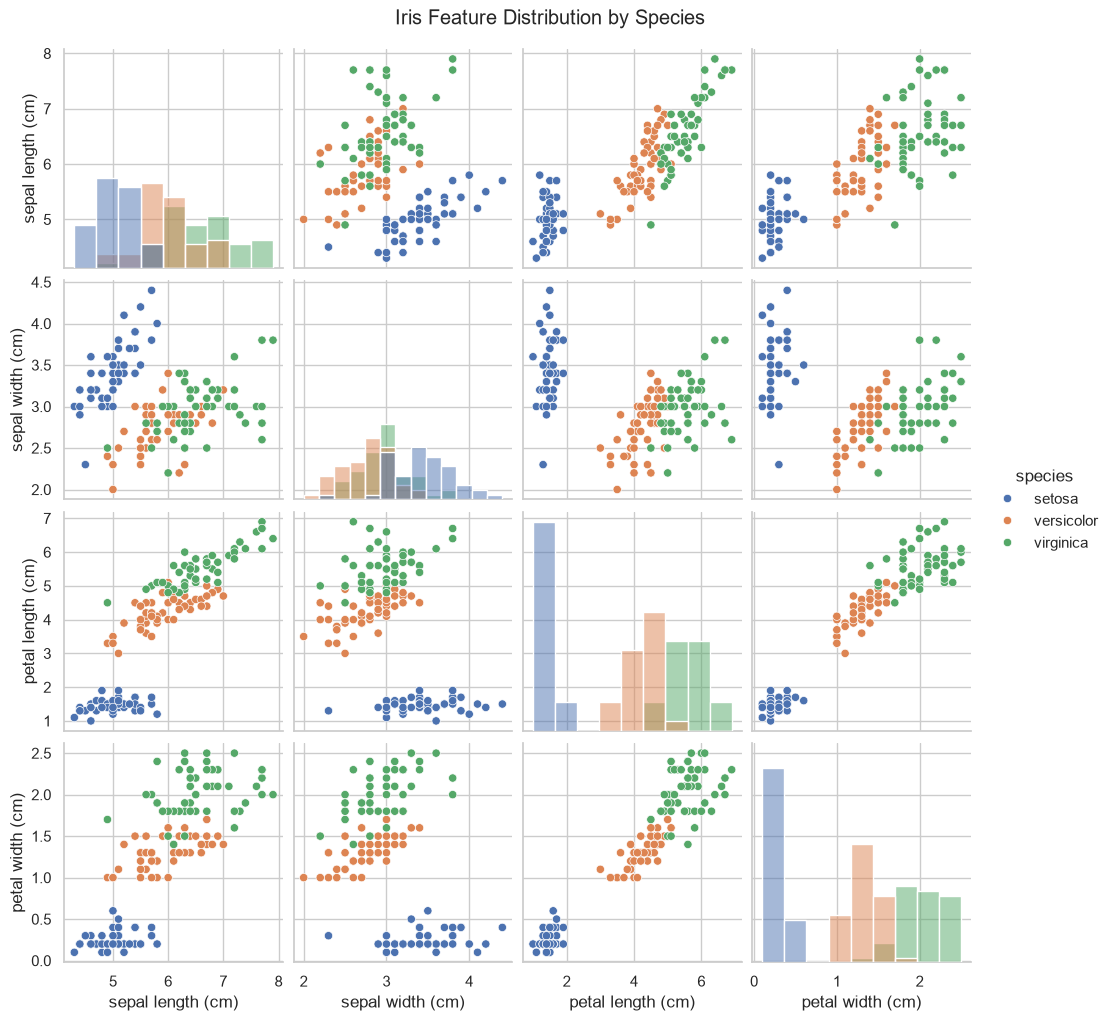

In [4]:
# Pairplot showing feature relationships by species
sns.pairplot(df, hue="species", diag_kind="hist")
plt.suptitle("Iris Feature Distribution by Species", y=1.02)
plt.show()

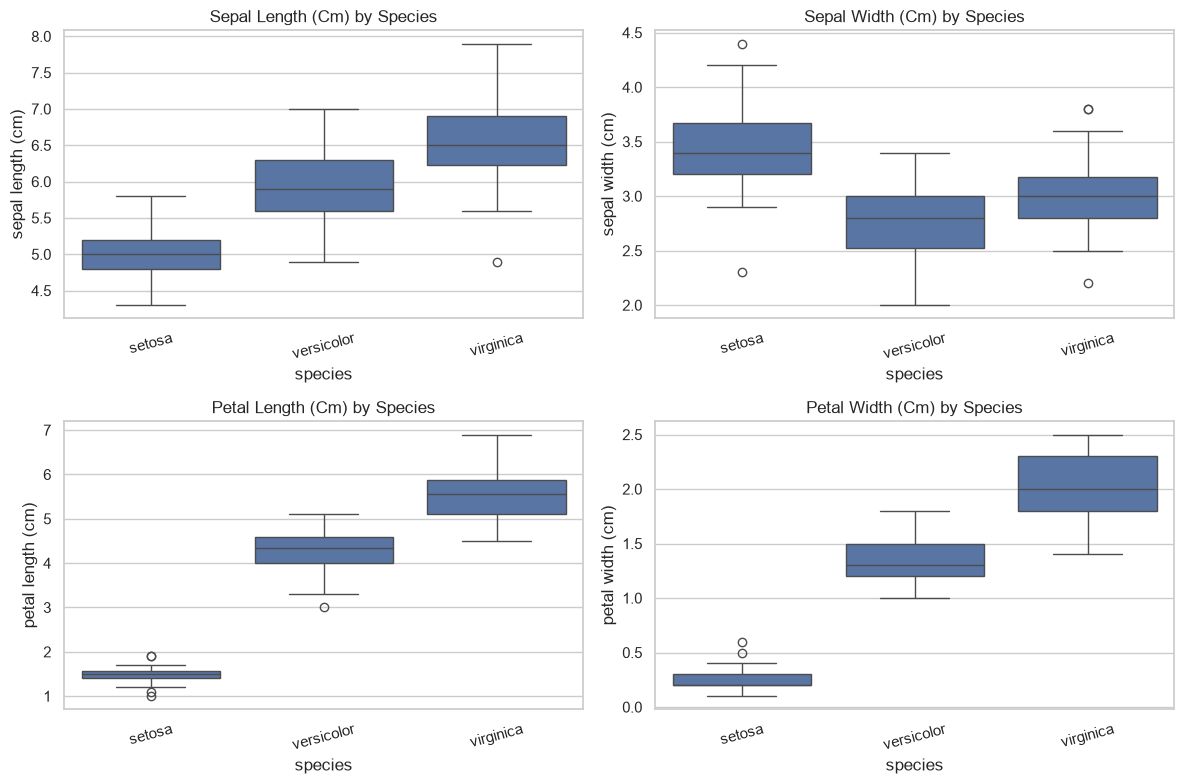

In [5]:
# Box plots for each feature
features = iris.feature_names

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="species", y=feature, ax=ax)
    ax.set_title(f"{feature.title()} by Species")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 4. Feature Discussion



### Which features are most discriminative?

From the pairplot and box plots:

- **Petal length** and **petal width** show the strongest separation between species.
- Setosa is especially easy to distinguish because it has much smaller petals.
- Versicolor and Virginica overlap more, but their petal measurements still provide strong separation.
- Sepal length and sepal width are useful, but generally less discriminative than petal measurements.

Therefore, **petal length and petal width are the most important features for this classification problem**.


## 5. Correlation Heatmap


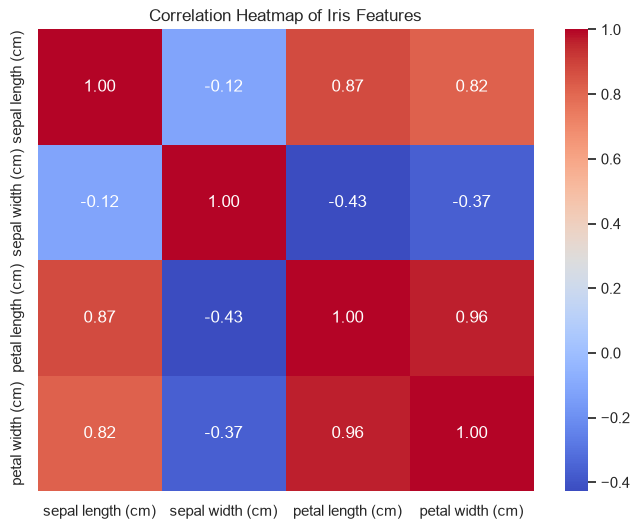

In [6]:

plt.figure(figsize=(8, 6))
corr = df[features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Iris Features")
plt.show()

## 6. Train-Test Split


In [7]:

X = df[features]
y = df["species"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 7. Train Multiple Classification Models

In [8]:

# Models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "K-Nearest Neighbours": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=4
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,K-Nearest Neighbours,0.933333,0.944444,0.933333,0.932660
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
3,Random Forest,0.900000,0.902357,0.900000,0.899749


## 8. Model Evaluation

In [9]:

# Select the best-performing model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

print("Best Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



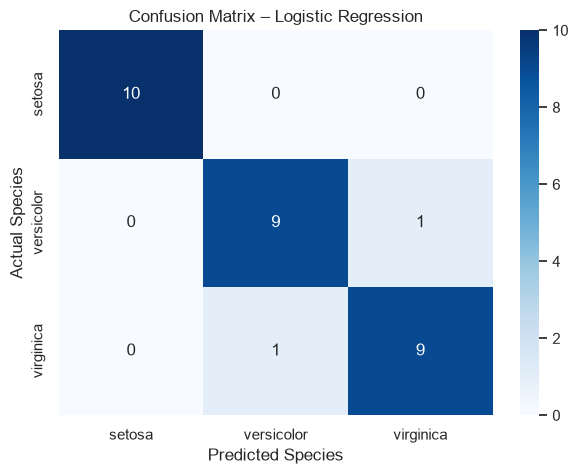

In [10]:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best, labels=iris.target_names)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()


## 9. Feature Importance

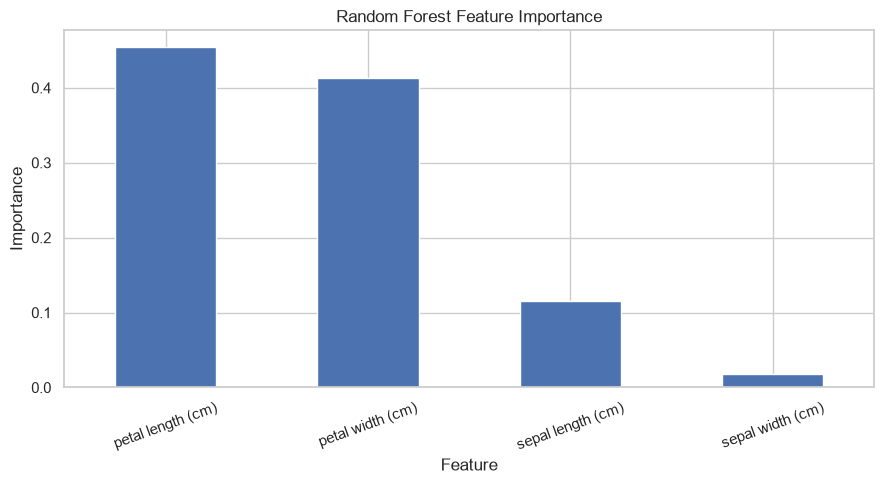

,Importance
petal length (cm),0.453793
petal width (cm),0.412449
sepal length (cm),0.115873
sepal width (cm),0.017885


In [11]:

# Use Random Forest to examine feature importance
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(importance.to_frame("Importance"))


## 10. Final Conclusion


### Conclusion

The Iris flower classification problem was successfully solved using multiple machine learning classification algorithms.

The workflow included:

1. Loading the Iris dataset using `sklearn.datasets.load_iris()`.
2. Performing EDA including shape, data types, null-value checking and descriptive statistics.
3. Visualizing feature distributions using pairplots and box plots.
4. Identifying **petal length and petal width** as the most discriminative features.
5. Splitting the dataset into **80% training and 20% testing data**.
6. Training four classifiers:
   - Logistic Regression
   - K-Nearest Neighbours
   - Decision Tree
   - Random Forest
7. Evaluating models using **accuracy, precision, recall, F1-score and confusion matrix**.
8. Examining feature importance using Random Forest.

### Best Model

The notebook automatically identifies the model with the highest test accuracy and prints its complete classification report. On this small and well-separated dataset, the models are expected to achieve very high accuracy.

**Overall, petal measurements provide the strongest information for distinguishing Iris species.**
